In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [132]:
df = pd.read_csv("Dataset of Diabetes.csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [133]:
# Basic understanding
print("-://////////////////////////////SHAPE/////////////////////////////////////:-")
print(df.shape)
print("-://////////////////////////////COLUMNS////////////////////////////////////:-")
print(df.columns)
print("-:///////////////////////////////INFO//////////////////////////////////////:-")
print(df.info())
print("-://///////////////////////////DESCRIBE////////////////////////////////////:-") #data types and missing values
print(df.describe())

-://////////////////////////////SHAPE/////////////////////////////////////:-
(1000, 14)
-://////////////////////////////COLUMNS////////////////////////////////////:-
Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='str')
-:///////////////////////////////INFO//////////////////////////////////////:-
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   str    
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   floa

In [134]:
#Separate numerical and categorical columns
num_cols = ["AGE", "Urea", "Cr", "HbA1c", "Chol", "TG", "HDL", "LDL", "VLDL", "BMI"]
cat_cols = ["Gender", "CLASS"]

In [135]:
print("-:///////////////////////CHECK GENDER FREQUENCY & TARGET CLASS//////////////////////////////:-")#This shows how many records belong to each class
print(df["Gender"].value_counts())
print(df["Gender"].value_counts(normalize=True) * 100)
print()
print(df["CLASS"].value_counts())
print(df["CLASS"].value_counts(normalize=True) * 100)


-:///////////////////////CHECK GENDER FREQUENCY & TARGET CLASS//////////////////////////////:-
Gender
M    565
F    434
f      1
Name: count, dtype: int64
Gender
M    56.5
F    43.4
f     0.1
Name: proportion, dtype: float64

CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64
CLASS
Y     84.0
N     10.2
P      5.3
Y      0.4
N      0.1
Name: proportion, dtype: float64


-:///////////////////////CHECK MISSING VALUES//////////////////////////////:-


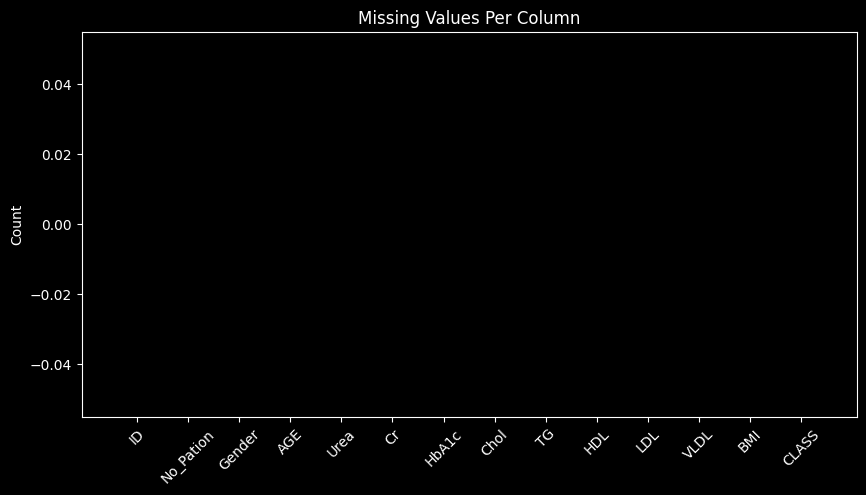

In [136]:
print("-:///////////////////////CHECK MISSING VALUES//////////////////////////////:-")
missing = df.isnull().sum()

plt.figure(figsize=(10,5))
plt.bar(missing.index, missing.values)
plt.xticks(rotation=45)
plt.title("Missing Values Per Column")
plt.ylabel("Count")
plt.show()

In [137]:
print("-:///////////////////////CHECK DUPLICATE ROWS//////////////////////////////:-")
df.duplicated().sum()

-:///////////////////////CHECK DUPLICATE ROWS//////////////////////////////:-


np.int64(0)

In [138]:
print("-:///////////////////////CHECK UNIQUE VALUES IN CATEGORICAL COLUMNS//////////////////////////////:-")
print(df["Gender"].unique())
print()
df["CLASS"].unique()

-:///////////////////////CHECK UNIQUE VALUES IN CATEGORICAL COLUMNS//////////////////////////////:-
<StringArray>
['F', 'M', 'f']
Length: 3, dtype: str



<StringArray>
['N', 'N ', 'P', 'Y', 'Y ']
Length: 5, dtype: str

In [139]:
#Full summary statistics for numerical columns
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
AGE,1000.0,53.528000,8.799241,20.0,51.0,55.0,59.0,79.00
Urea,1000.0,5.124743,2.935165,0.5,3.7,4.6,5.7,38.90
Cr,1000.0,68.943000,59.984747,6.0,48.0,60.0,73.0,800.00
HbA1c,1000.0,8.281160,2.534003,0.9,6.5,8.0,10.2,16.00
Chol,1000.0,4.862820,1.301738,0.0,4.0,4.8,5.6,10.30
TG,1000.0,2.349610,1.401176,0.3,1.5,2.0,2.9,13.80
HDL,1000.0,1.204750,0.660414,0.2,0.9,1.1,1.3,9.90
LDL,1000.0,2.609790,1.115102,0.3,1.8,2.5,3.3,9.90
VLDL,1000.0,1.854700,3.663599,0.1,0.7,0.9,1.5,35.00
BMI,1000.0,29.578020,4.962388,19.0,26.0,30.0,33.0,47.75


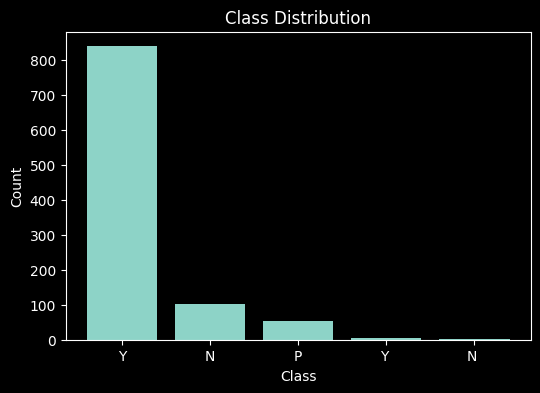

In [140]:
#Class distribution
class_counts = df["CLASS"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

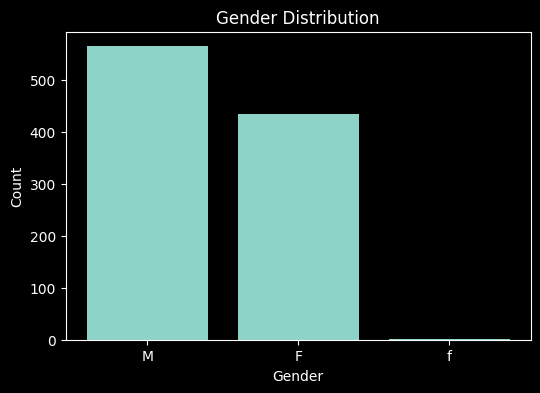

In [141]:
#Gender distribution
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

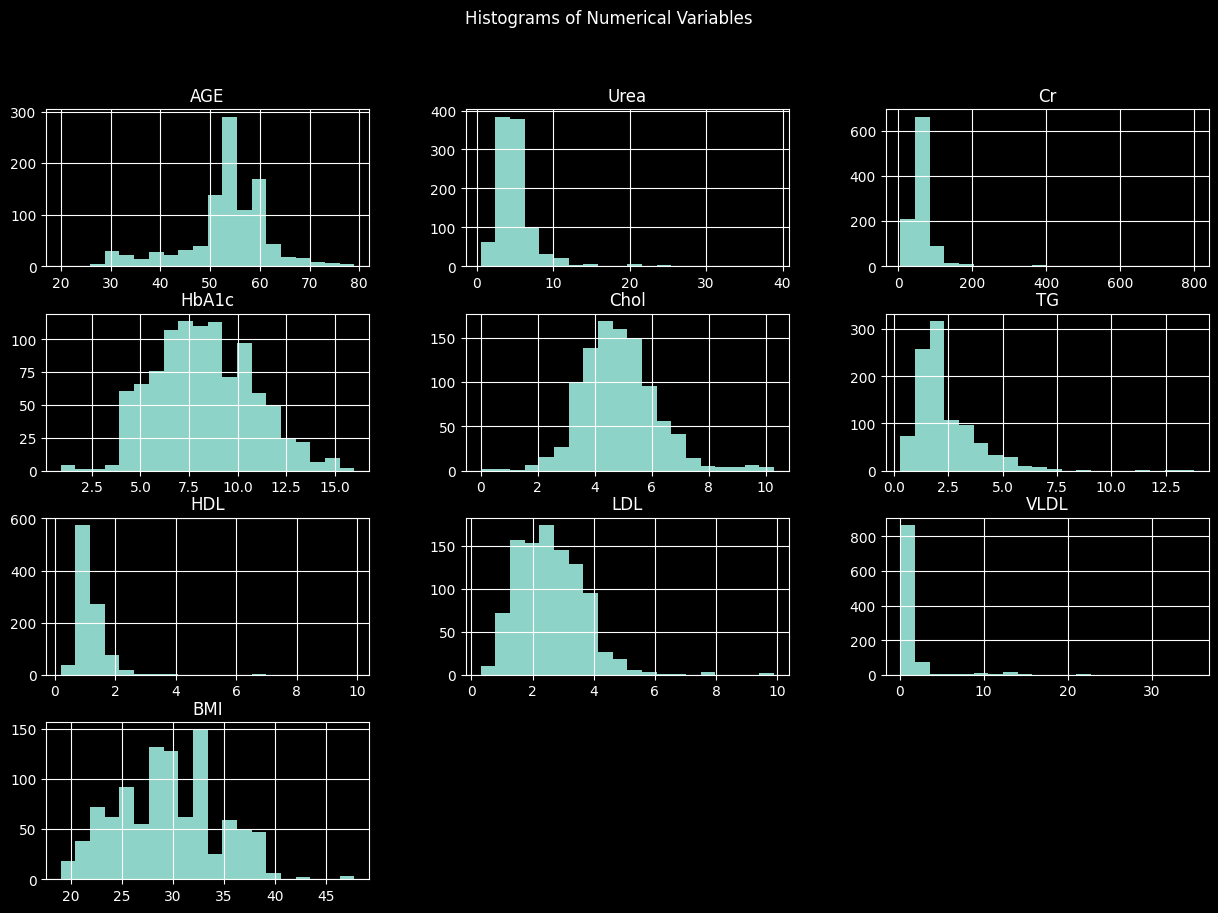

In [142]:
#Histograms for Numerical Vairables
df[num_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Histograms of Numerical Variables")
plt.show()

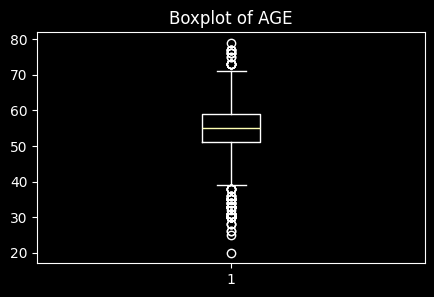

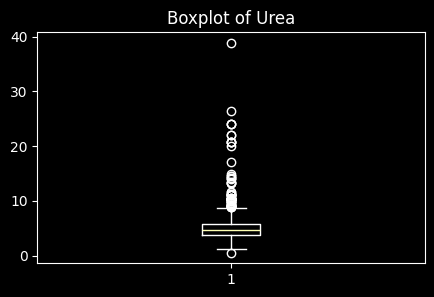

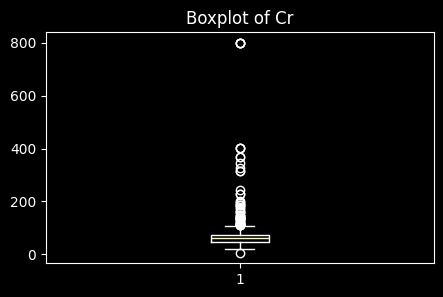

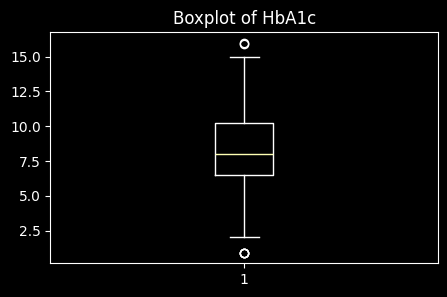

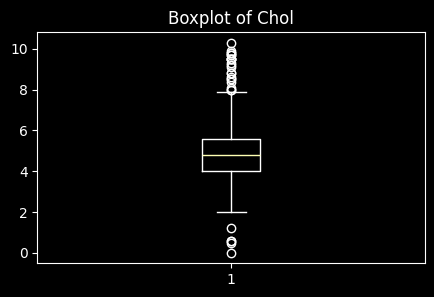

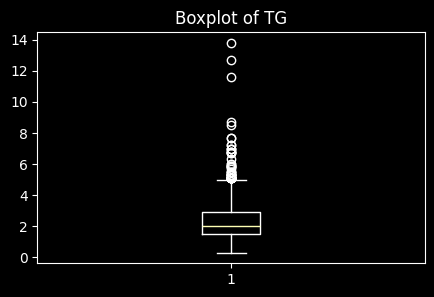

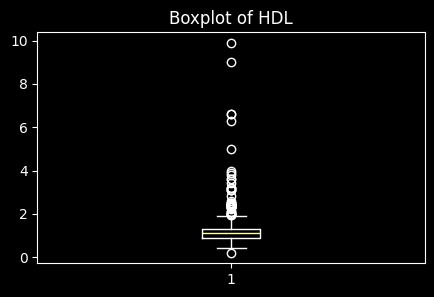

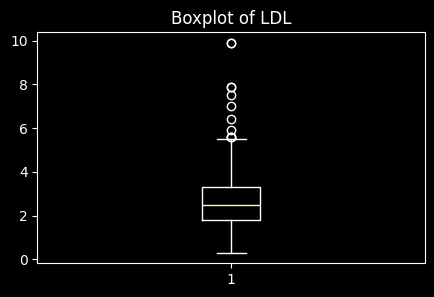

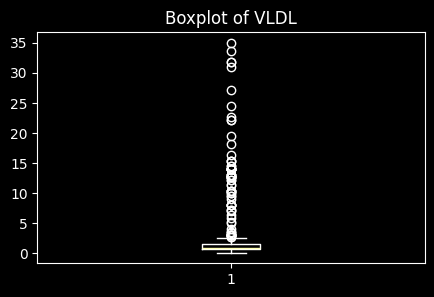

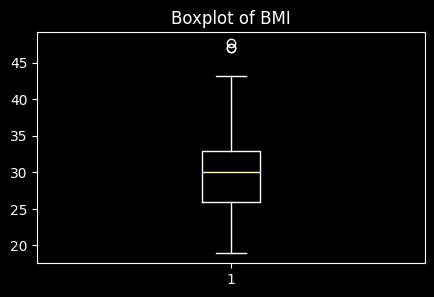

In [143]:
#Outlier Detection using BOX PLOT
for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")

    plt.show()

In [144]:
#Detect outliers using IQR
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers.shape[0]
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,AGE,51.0,59.0,8.0,39.00,71.00,98
1,Urea,3.7,5.7,2.0,0.70,8.70,65
2,Cr,48.0,73.0,25.0,10.50,110.50,52
3,HbA1c,6.5,10.2,3.7,0.95,15.75,6
4,Chol,4.0,5.6,1.6,1.60,8.00,27
5,TG,1.5,2.9,1.4,-0.60,5.00,55
6,HDL,0.9,1.3,0.4,0.30,1.90,50
7,LDL,1.8,3.3,1.5,-0.45,5.55,11
8,VLDL,0.7,1.5,0.8,-0.50,2.70,74
9,BMI,26.0,33.0,7.0,15.50,43.50,3


# **CORRELATION ANALYSIS**
What to look for:

values near 1 → strong positive relation

values near 0 → weak relation

values near -1 → strong negative relation

In [145]:
corr_matrix = df[num_cols].corr()
corr_matrix

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
AGE,1.000000,0.105092,0.054941,0.379136,0.036649,0.148204,-0.020038,0.016105,-0.087903,0.375956
Urea,0.105092,1.000000,0.624134,-0.023603,0.001852,0.040980,-0.036994,-0.007301,-0.011191,0.045618
Cr,0.054941,0.624134,1.000000,-0.037412,-0.007097,0.056579,-0.023804,0.039479,0.009615,0.054746
HbA1c,0.379136,-0.023603,-0.037412,1.000000,0.177489,0.218556,0.028933,0.011057,0.073462,0.413350
Chol,0.036649,0.001852,-0.007097,0.177489,1.000000,0.321789,0.103814,0.416665,0.076294,0.013678
TG,0.148204,0.040980,0.056579,0.218556,0.321789,1.000000,-0.083001,0.015378,0.144570,0.110757
HDL,-0.020038,-0.036994,-0.023804,0.028933,0.103814,-0.083001,1.000000,-0.142079,-0.059275,0.072409
LDL,0.016105,-0.007301,0.039479,0.011057,0.416665,0.015378,-0.142079,1.000000,0.062795,-0.067322
VLDL,-0.087903,-0.011191,0.009615,0.073462,0.076294,0.144570,-0.059275,0.062795,1.000000,0.198133
BMI,0.375956,0.045618,0.054746,0.413350,0.013678,0.110757,0.072409,-0.067322,0.198133,1.000000


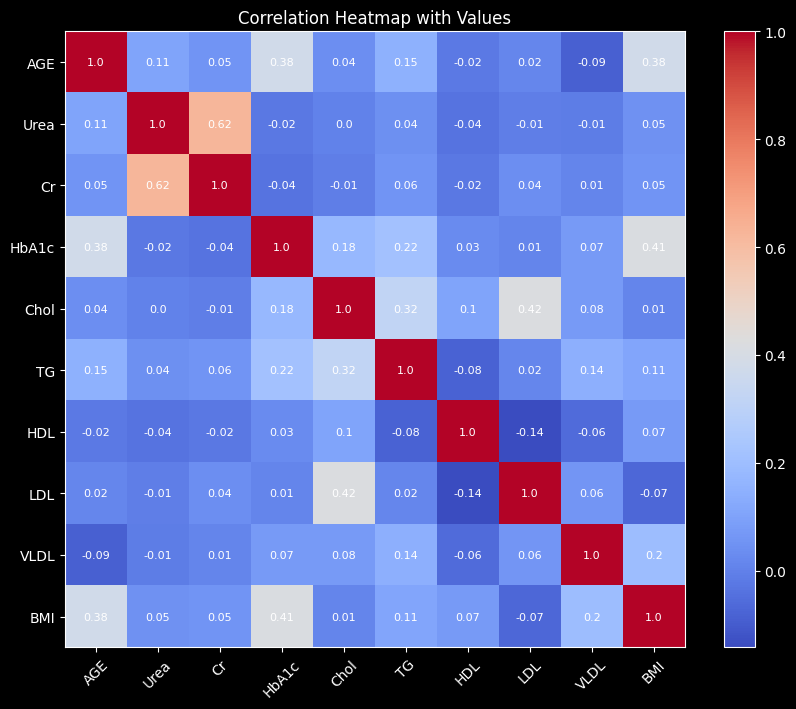

In [146]:
plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2),
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap with Values")
plt.show()
plt.show()

EXAMPLE SCATTER PLOTS

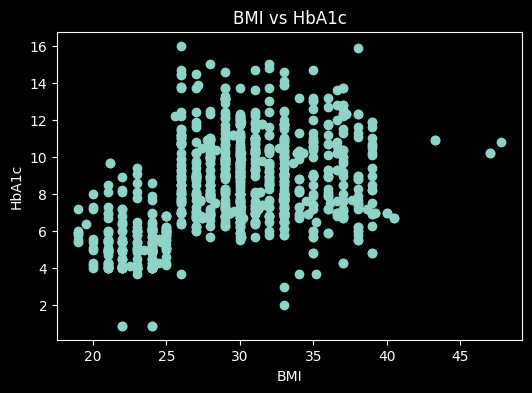

In [147]:
#BMI vs HbA1c
plt.figure(figsize=(6,4))
plt.scatter(df["BMI"], df["HbA1c"])
plt.xlabel("BMI")
plt.ylabel("HbA1c")
plt.title("BMI vs HbA1c")
plt.show()

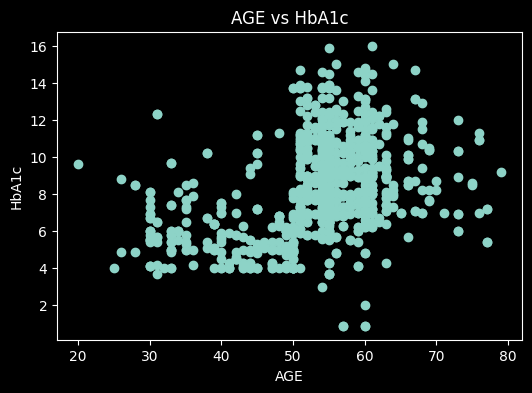

In [148]:
#AGE vs HbA1c
plt.figure(figsize=(6,4))
plt.scatter(df["AGE"], df["HbA1c"])
plt.xlabel("AGE")
plt.ylabel("HbA1c")
plt.title("AGE vs HbA1c")
plt.show()

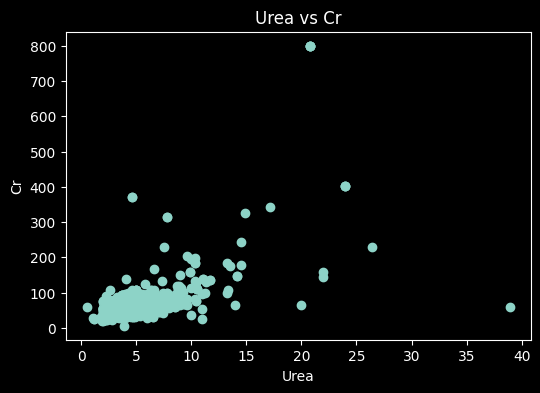

In [149]:
#Urea vs Cr
plt.figure(figsize=(6,4))
plt.scatter(df["Urea"], df["Cr"])
plt.xlabel("Urea")
plt.ylabel("Cr")
plt.title("Urea vs Cr")
plt.show()

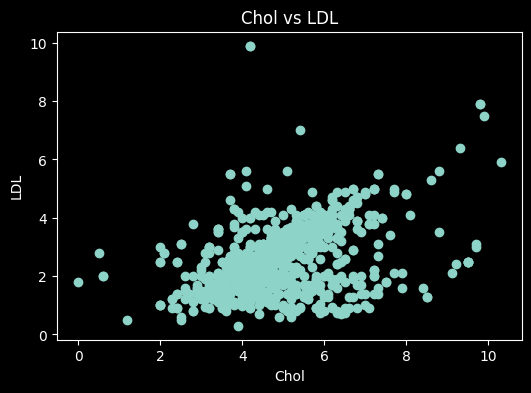

In [150]:
#Chol vs LDL
plt.figure(figsize=(6,4))
plt.scatter(df["Chol"], df["LDL"])
plt.xlabel("Chol")
plt.ylabel("LDL")
plt.title("Chol vs LDL")
plt.show()


# **Age group analysis**


In [151]:
bins = [0, 39, 49, 59, 100]
labels = ["20-39", "40-49", "50-59", "60+"]
df["Age_Group"] = pd.cut(df["AGE"], bins=bins, labels=labels)
df["Age_Group"].value_counts().sort_index()


Age_Group
20-39     88
40-49    107
50-59    569
60+      236
Name: count, dtype: int64

In [152]:
age_class_table = pd.crosstab(df["Age_Group"], df["CLASS"])
age_class_table

CLASS,N,N,P,Y,Y
Age_Group,,,,,
20-39,27,1,18,39,3
40-49,46,0,17,44,0
50-59,24,0,18,526,1
60+,5,0,0,231,0


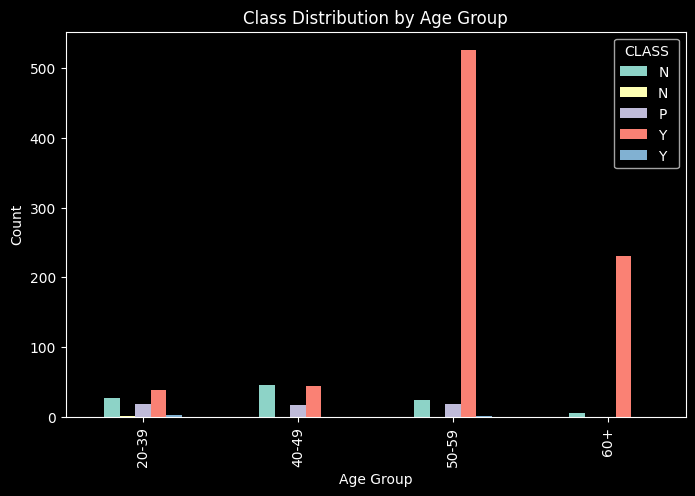

In [153]:
age_class_table.plot(kind="bar", figsize=(8,5))
plt.title("Class Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

# **Gender vs Class analysis**

In [154]:
gender_class_table = pd.crosstab(df["Gender"], df["CLASS"])
gender_class_table

CLASS,N,N,P,Y,Y
Gender,,,,,
F,64,0,17,353,0
M,38,1,36,486,4
f,0,0,0,1,0


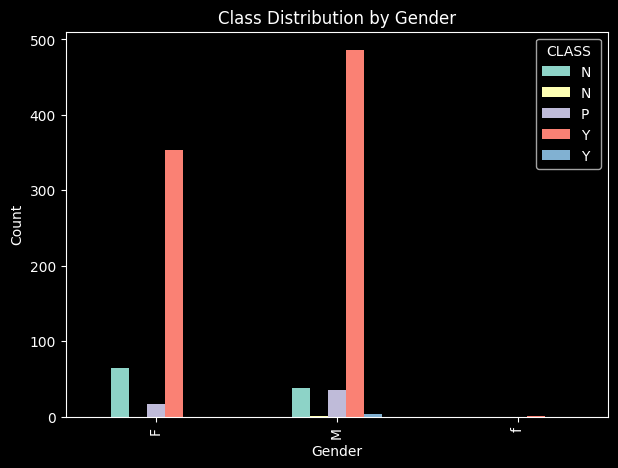

In [155]:
gender_class_table.plot(kind="bar", figsize=(7,5))
plt.title("Class Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()